# Simple Linear Regression II: Python Companion
**ENGR 1451/2451 · Exploratory Data Science · w06b**

The **slides focus on concepts**. This notebook focuses on the Python needed to:

- fit a simple linear regression with `statsmodels`,
- extract the slope, intercept, RMSE, and \(R^2\),
- calculate fitted values and residuals,
- make a few diagnostic plots, and
- refit the model for a simple sensitivity check.

We continue the 2017 state/DC poverty versus HS graduation example from w06a.


In [16]:
from pathlib import Path
from scipy import stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import scipy.stats as stats

pd.set_option("display.precision", 3)

counties = pd.read_csv(Path("data/county_complete.csv"))


## 1. Prepare the 2017 state-level data

This is the same aggregation used in w06a. The regression itself gives each state/DC one observation.


In [17]:
year = "2017"
pop_col = f"pop{year}"
hs_col = f"hs_grad_{year}"
poverty_col = f"poverty_{year}"

county_data = counties[
    ["state", pop_col, hs_col, poverty_col]
].dropna().copy()

county_data["hs_total"] = county_data[hs_col] * county_data[pop_col]
county_data["poverty_total"] = county_data[poverty_col] * county_data[pop_col]

state_data = (
    county_data
    .groupby("state", as_index=False)
    .agg(
        population=(pop_col, "sum"),
        hs_total=("hs_total", "sum"),
        poverty_total=("poverty_total", "sum"),
    )
)

state_data["hs_grad"] = state_data["hs_total"] / state_data["population"]
state_data["poverty"] = state_data["poverty_total"] / state_data["population"]

state_data = state_data[["state", "hs_grad", "poverty"]]
state_data.head()


,state,hs_grad,poverty
0,Alabama,85.419,17.926
1,Alaska,92.449,9.866
2,Arizona,86.485,16.925
3,Arkansas,85.646,18.098
4,California,82.319,15.116


## 2. Fit the regression with `statsmodels`

Formula syntax is `response ~ predictor`, similar to R's `lm()`.


In [18]:
fit = smf.ols("poverty ~ hs_grad", data=state_data).fit()

rmse = np.sqrt(np.mean(fit.resid**2))

results = pd.Series({
    "Intercept": fit.params["Intercept"],
    "Slope": fit.params["hs_grad"],
    "RMSE": rmse,
    "R-squared": fit.rsquared,
})

results


Intercept    85.789
Slope        -0.807
RMSE          1.897
R-squared     0.599
dtype: float64

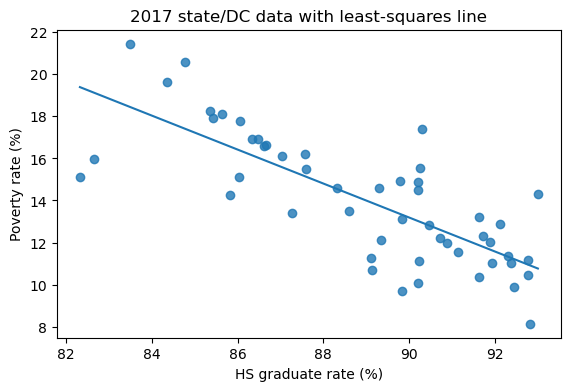

In [19]:
x_grid = np.linspace(state_data["hs_grad"].min(),
                     state_data["hs_grad"].max(), 100)
prediction_data = pd.DataFrame({"hs_grad": x_grid})

plt.figure(figsize=(6.5, 4))
plt.scatter(state_data["hs_grad"], state_data["poverty"], alpha=0.8)
plt.plot(x_grid, fit.predict(prediction_data))
plt.xlabel("HS graduate rate (%)")
plt.ylabel("Poverty rate (%)")
plt.title("2017 state/DC data with least-squares line")
plt.show()


## 3. Work with fitted values and residuals


In [20]:
state_data = state_data.assign(
    fitted=fit.fittedvalues,
    residual=fit.resid,
)

state_data[["state", "poverty", "fitted", "residual"]].head()


,state,poverty,fitted,residual
0,Alabama,17.926,16.888,1.038
1,Alaska,9.866,11.217,-1.351
2,Arizona,16.925,16.028,0.897
3,Arkansas,18.098,16.705,1.394
4,California,15.116,19.389,-4.272


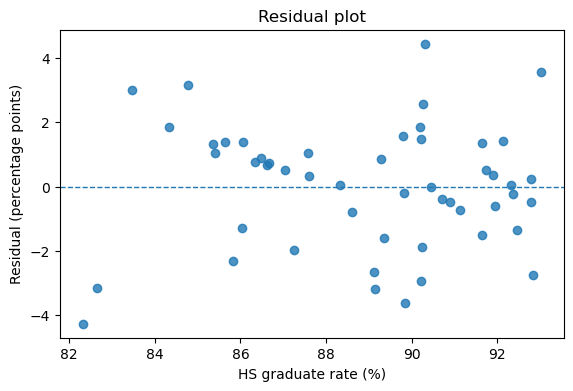

In [21]:
plt.figure(figsize=(6.5, 4))
plt.scatter(state_data["hs_grad"], state_data["residual"], alpha=0.8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("HS graduate rate (%)")
plt.ylabel("Residual (percentage points)")
plt.title("Residual plot")
plt.show()


## 4. Two quick shape checks

The slides explain what these displays mean.


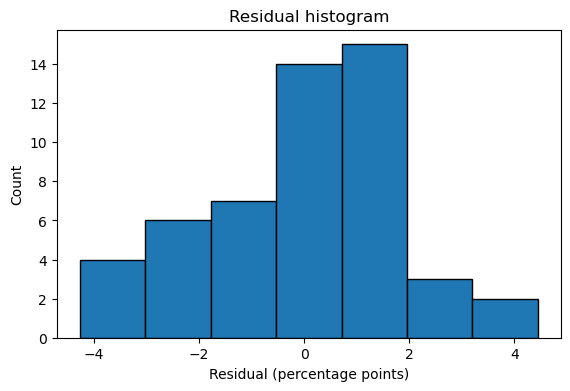

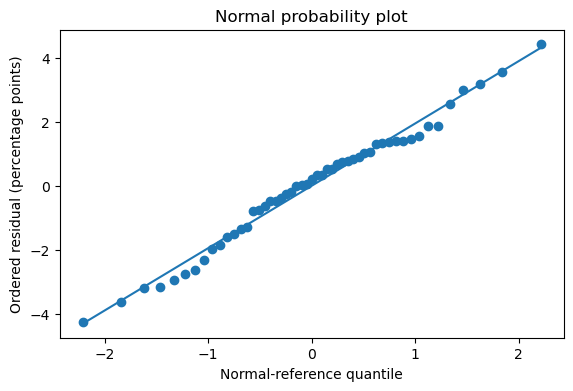

In [22]:
# Histogram
plt.figure(figsize=(6.5, 4))
plt.hist(state_data["residual"], bins="auto", edgecolor="black")
plt.xlabel("Residual (percentage points)")
plt.ylabel("Count")
plt.title("Residual histogram")
plt.show()

# Normal probability (Q-Q) plot
(theoretical, ordered), (slope, intercept, r) = stats.probplot(
    state_data["residual"], dist="norm", fit=True
)

plt.figure(figsize=(6.5, 4))
plt.scatter(theoretical, ordered)

# Reference line
x = np.array([theoretical.min(), theoretical.max()])
plt.plot(x, intercept + slope * x)

plt.xlabel("Normal-reference quantile")
plt.ylabel("Ordered residual (percentage points)")
plt.title("Normal probability plot")
plt.show()


## 5. Simple sensitivity check

Refit after removing one observation and compare the fitted coefficients.


In [23]:
def exclude_state(state_to_check):
    

    reduced_data = state_data.loc[state_data["state"] != state_to_check]
    fit_without = smf.ols("poverty ~ hs_grad", data=reduced_data).fit()

    comparison = pd.DataFrame({
        "All states and DC": fit.params,
        f"Without {state_to_check}": fit_without.params,
    })
    display(comparison)
    return()
state_to_check = state_data.loc[
        state_data["residual"].abs().idxmax(), "state"
    ]
exclude_state(state_to_check)



,All states and DC,Without District of Columbia
Intercept,85.789,87.027
hs_grad,-0.807,-0.822


()

In [25]:
#1. predict poverty rate
given_hs_grad = 90
predicted_pov_rate = results["Slope"]*given_hs_grad + results["Intercept"]
print(f"Given a high school grade rate of {given_hs_grad}, the predicted poverty rate is {predicted_pov_rate:.3f}")
#print(results["Slope"])
#new_data = pd.DataFrame({"hs_grad", [90]})
#fit.predict(new_data)
#display(new_data)

#2. find states w/ largest residuals
#print(state_data["residual"]) #to see what this data looks like
#residuals are above and below fit line
#key from pandas docs - allows customization of sorting
sorted_state_data = state_data.sort_values(by = 'residual', key = abs, ascending = False)
display(sorted_state_data.head())

#3. Change state to check
#changed above to a function so the code can be reused
exclude_state("California")

Given a high school grade rate of 90, the predicted poverty rate is 13.193


,state,hs_grad,poverty,fitted,residual
8,District of Columbia,90.300,17.400,12.951,4.449
4,California,82.319,15.116,19.389,-4.272
20,Maryland,89.832,9.697,13.328,-3.632
26,Montana,93.008,14.332,10.767,3.565
30,New Jersey,89.138,10.692,13.888,-3.196


,All states and DC,Without California
Intercept,85.789,92.663
hs_grad,-0.807,-0.883


()

## 6. Practice

Use the fitted model and the objects already created above.

1. Predict the poverty rate when `hs_grad = 90`.
2. Find the five states/DC with the largest absolute residuals.
3. Change `state_to_check` to another state and compare the new slope with the original slope.

### Core Python patterns

| Task | Python |
|---|---|
| Fit the model | `smf.ols("poverty ~ hs_grad", data=state_data).fit()` |
| Coefficients | `fit.params` |
| Fitted values | `fit.fittedvalues` |
| Residuals | `fit.resid` |
| \(R^2\) | `fit.rsquared` |
| Predict | `fit.predict(new_data)` |
